In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utils

## Setup plot defaults
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

In [13]:
conc_df_path = 'data/GHG_Concentrations/SUPPLEMENT_DataTables_Meinshausen_6May2020.xlsx'
conc_df = pd.read_excel(conc_df_path, sheet_name='T11 - SSP5-8.5', skiprows=np.arange(11))

In [25]:
u1 = conc_df['Unnamed: 1'][0:85]
u1_np = u1.to_numpy()

In [67]:
utils.toeplitz_rank(u1_np.reshape(1,-1),43)

np.int64(43)

In [70]:
utils.toeplitz_rank((u2.reshape(1,-1)),43)

np.int64(2)

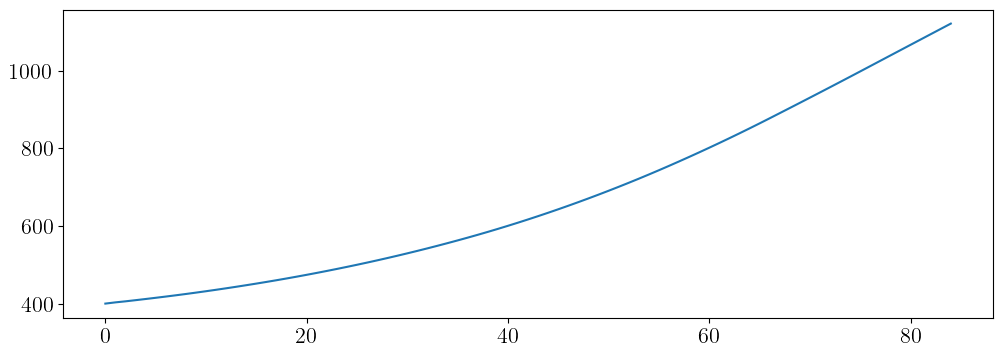

In [52]:
plt.plot(u1_np)

In [53]:
from scipy.optimize import curve_fit
def exponential_func(x, a, b, c):
  return a * np.exp(b * x) + c

popt, pcov = curve_fit(exponential_func, np.arange(0,len(u1_np)), u1_np, p0=[1, 0.5, 0])
a_fit, b_fit, c_fit = popt
u2 = exponential_func(np.arange(0,len(u1_np)), a_fit, b_fit, c_fit)

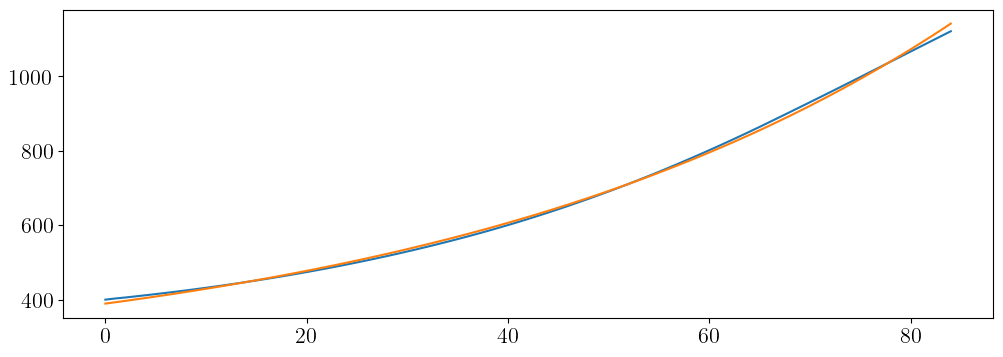

In [57]:

plt.plot(u1_np)
plt.plot(u2)


In [102]:
u = np.arange(10) + 1
k = len(u)
pad = np.zeros(k-1)

In [93]:
u_pad = np.hstack((pad, u))
idx = 0 + k - 1

In [94]:
lag_vec = u_pad[idx : idx - k : -1]

In [95]:
lag_vec

array([], dtype=float64)

In [108]:
t = 9
pad = k - 1                       # how many zeros we need on the left
u_ext = np.hstack((np.zeros(pad), u))

idx0 = t + pad                    # position of u_t in the padded series
idxs = idx0 - np.arange(k)        # [idx0, idx0-1, …, idx0-k+1]
lag = np.take(u_ext, idxs)        # shape (k,)

In [114]:
idx

10

In [116]:
u_ext[idx - (k-1): idx + 1][::-1]

array([2., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [119]:
t = 0
pad = k - 1                       # zeros needed on the left
u_ext = np.concatenate((np.zeros(pad), u))

idx = t + pad                     # position of u_t in the padded series
lag = u_ext[idx - (k-1): idx + 1][::-1]
np.outer(lag, lag)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [154]:
compute_Fisher_full(u1_np, 1)

array([[42146981.12641655, 41434355.63341203, 40728465.09811536, ...,
         1339355.32746256,   895215.03618254,   448562.53781808],
       [41434355.63341203, 40889106.88820609, 40191801.80553531, ...,
         1322826.23390086,   884237.12359157,   443099.22365601],
       [40728465.09811536, 40191801.80553531, 39661686.87412933, ...,
         1306289.01692072,   873251.18960962,   437627.90270662],
       ...,
       [ 1339355.32746256,  1322826.23390086,  1306289.01692072, ...,
          487131.08127313,   324808.58609092,   162296.81023281],
       [  895215.03618254,   884237.12359157,   873251.18960962, ...,
          324808.58609092,   322462.33045315,   161226.1465368 ],
       [  448562.53781808,   443099.22365601,   437627.90270662, ...,
          162296.81023281,   161226.1465368 ,   159959.03582544]],
      shape=(85, 85))

In [156]:
F_u1 = compute_Fisher_full(u1_np, 1)
print(utils.compute_A_optimality(F_u1))
print(utils.compute_D_optimality(F_u1))
print(utils.compute_E_optimality(F_u1))

0.0010648751878759156
inf
39612.358584084745


In [203]:
2*N*np.log(N)

np.float64(295.1103563291149)